In [3]:
import pandas as pd
import numpy as np
import os

# 1. Address (Paths) ko sahi folder par point karo
data_dir = './Data/'  # 'Data' folder ka naam hamesha yaad rakhna hai
files = {
    'Application Train': os.path.join(data_dir, 'application_train.csv'),
    'Bureau': os.path.join(data_dir, 'bureau.csv')
}

print("--- STARTING STRUCTURAL DATA AUDIT ---")

for name, path in files.items():
    if os.path.exists(path):
        # Pehle test ke liye sirf 10k rows load kar rahe hain
        df = pd.read_csv(path, nrows=10000) 
        rows, cols = df.shape
        memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
        
        print(f"\n📊 REPORT FOR: {name.upper()}")
        print(f"🔹 Total Columns (Features): {cols}")
        print(f"🔹 RAM Memory Occupied (Test 10k Rows): {memory_mb:.2f} MB")
        print(f"🔹 Data Types Breakdown:\n{df.dtypes.value_counts().to_string()}")
    else:
        print(f"❌ Error: File '{name}' is path par nahi mili: {path}")

--- STARTING STRUCTURAL DATA AUDIT ---

📊 REPORT FOR: APPLICATION TRAIN
🔹 Total Columns (Features): 122
🔹 RAM Memory Occupied (Test 10k Rows): 16.42 MB
🔹 Data Types Breakdown:
float64    65
int64      41
object     16

📊 REPORT FOR: BUREAU
🔹 Total Columns (Features): 17
🔹 RAM Memory Occupied (Test 10k Rows): 2.75 MB
🔹 Data Types Breakdown:
float64    8
int64      6
object     3


In [4]:
import pandas as pd
import numpy as np

# Sahi folder path se dono files poori load karte hain (Bina nrows ke)
print("--- LOADING FULL DATASETS FOR OPTIMIZATION ---")
df_train = pd.read_csv('./Data/application_train.csv')
df_bureau = pd.read_csv('./Data/bureau.csv')

def optimize_and_audit(df, name):
    start_mem = df.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"\n==========================================")
    print(f"🛠️ OPTIMIZING: {name.upper()}")
    print(f"==========================================")
    print(f"🔹 Original Memory: {start_mem:.2f} MB")
    
    # 1. Downcasting Loop (Backend Optimization)
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            
            # Integer type ko downcast karna
            if str(col_type).startswith('int'):
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            # Float type ko downcast karna
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                    
    end_mem = df.memory_usage(deep=True).sum() / (1024 ** 2)
    savings = ((start_mem - end_mem) / start_mem) * 100
    print(f"✅ Optimized Memory: {end_mem:.2f} MB (Reduced by {savings:.1f}%)")
    
    # 2. Missing Value Analysis
    missing_series = df.isnull().sum()
    missing_df = pd.DataFrame({
        'Missing Values': missing_series,
        'Percentage (%)': (missing_series / len(df)) * 100
    }).sort_values(by='Percentage (%)', ascending=False)
    
    # Sirf woh columns dikhao jahan data sach mein missing hai
    missing_df = missing_df[missing_df['Missing Values'] > 0]
    
    print(f"\n⚠️ Top 5 Columns with Most Missing Data:")
    print(missing_df.head(5).to_string())
    
    return df, missing_df

# Dono dataframes ko process karna
df_train, train_missing = optimize_and_audit(df_train, 'Application Train')
df_bureau, bureau_missing = optimize_and_audit(df_bureau, 'Bureau')

--- LOADING FULL DATASETS FOR OPTIMIZATION ---

🛠️ OPTIMIZING: APPLICATION TRAIN
🔹 Original Memory: 504.99 MB


C:\Users\User\AppData\Local\Temp\ipykernel_9908\2356866384.py:34: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
C:\Users\User\AppData\Local\Temp\ipykernel_9908\2356866384.py:34: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
C:\Users\User\AppData\Local\Temp\ipykernel_9908\2356866384.py:34: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
C:\Users\User\AppData\Local\Temp\ipykernel_9908\2356866384.py:34: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:


✅ Optimized Memory: 311.14 MB (Reduced by 38.4%)

⚠️ Top 5 Columns with Most Missing Data:
                          Missing Values  Percentage (%)
COMMONAREA_MEDI                   214865       69.872297
COMMONAREA_AVG                    214865       69.872297
COMMONAREA_MODE                   214865       69.872297
NONLIVINGAPARTMENTS_MODE          213514       69.432963
NONLIVINGAPARTMENTS_AVG           213514       69.432963

🛠️ OPTIMIZING: BUREAU
🔹 Original Memory: 472.82 MB


C:\Users\User\AppData\Local\Temp\ipykernel_9908\2356866384.py:34: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
C:\Users\User\AppData\Local\Temp\ipykernel_9908\2356866384.py:34: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
C:\Users\User\AppData\Local\Temp\ipykernel_9908\2356866384.py:34: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
C:\Users\User\AppData\Local\Temp\ipykernel_9908\2356866384.py:34: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
C:\Users\User\AppData\Local\Temp\ipykernel_9908\2356866384.py:34: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
C:\Users\User\AppData\Local\Temp\ipykernel_9908\2356866384.py:34:

✅ Optimized Memory: 363.15 MB (Reduced by 23.2%)

⚠️ Top 5 Columns with Most Missing Data:
                        Missing Values  Percentage (%)
AMT_ANNUITY                    1226791       71.473490
AMT_CREDIT_MAX_OVERDUE         1124488       65.513264
DAYS_ENDDATE_FACT               633653       36.916958
AMT_CREDIT_SUM_LIMIT            591780       34.477415
AMT_CREDIT_SUM_DEBT             257669       15.011932


Matplotlib is building the font cache; this may take a moment.


--- GENERATING MISSING DATA VISUALIZATIONS ---


<Figure size 1500x600 with 0 Axes>

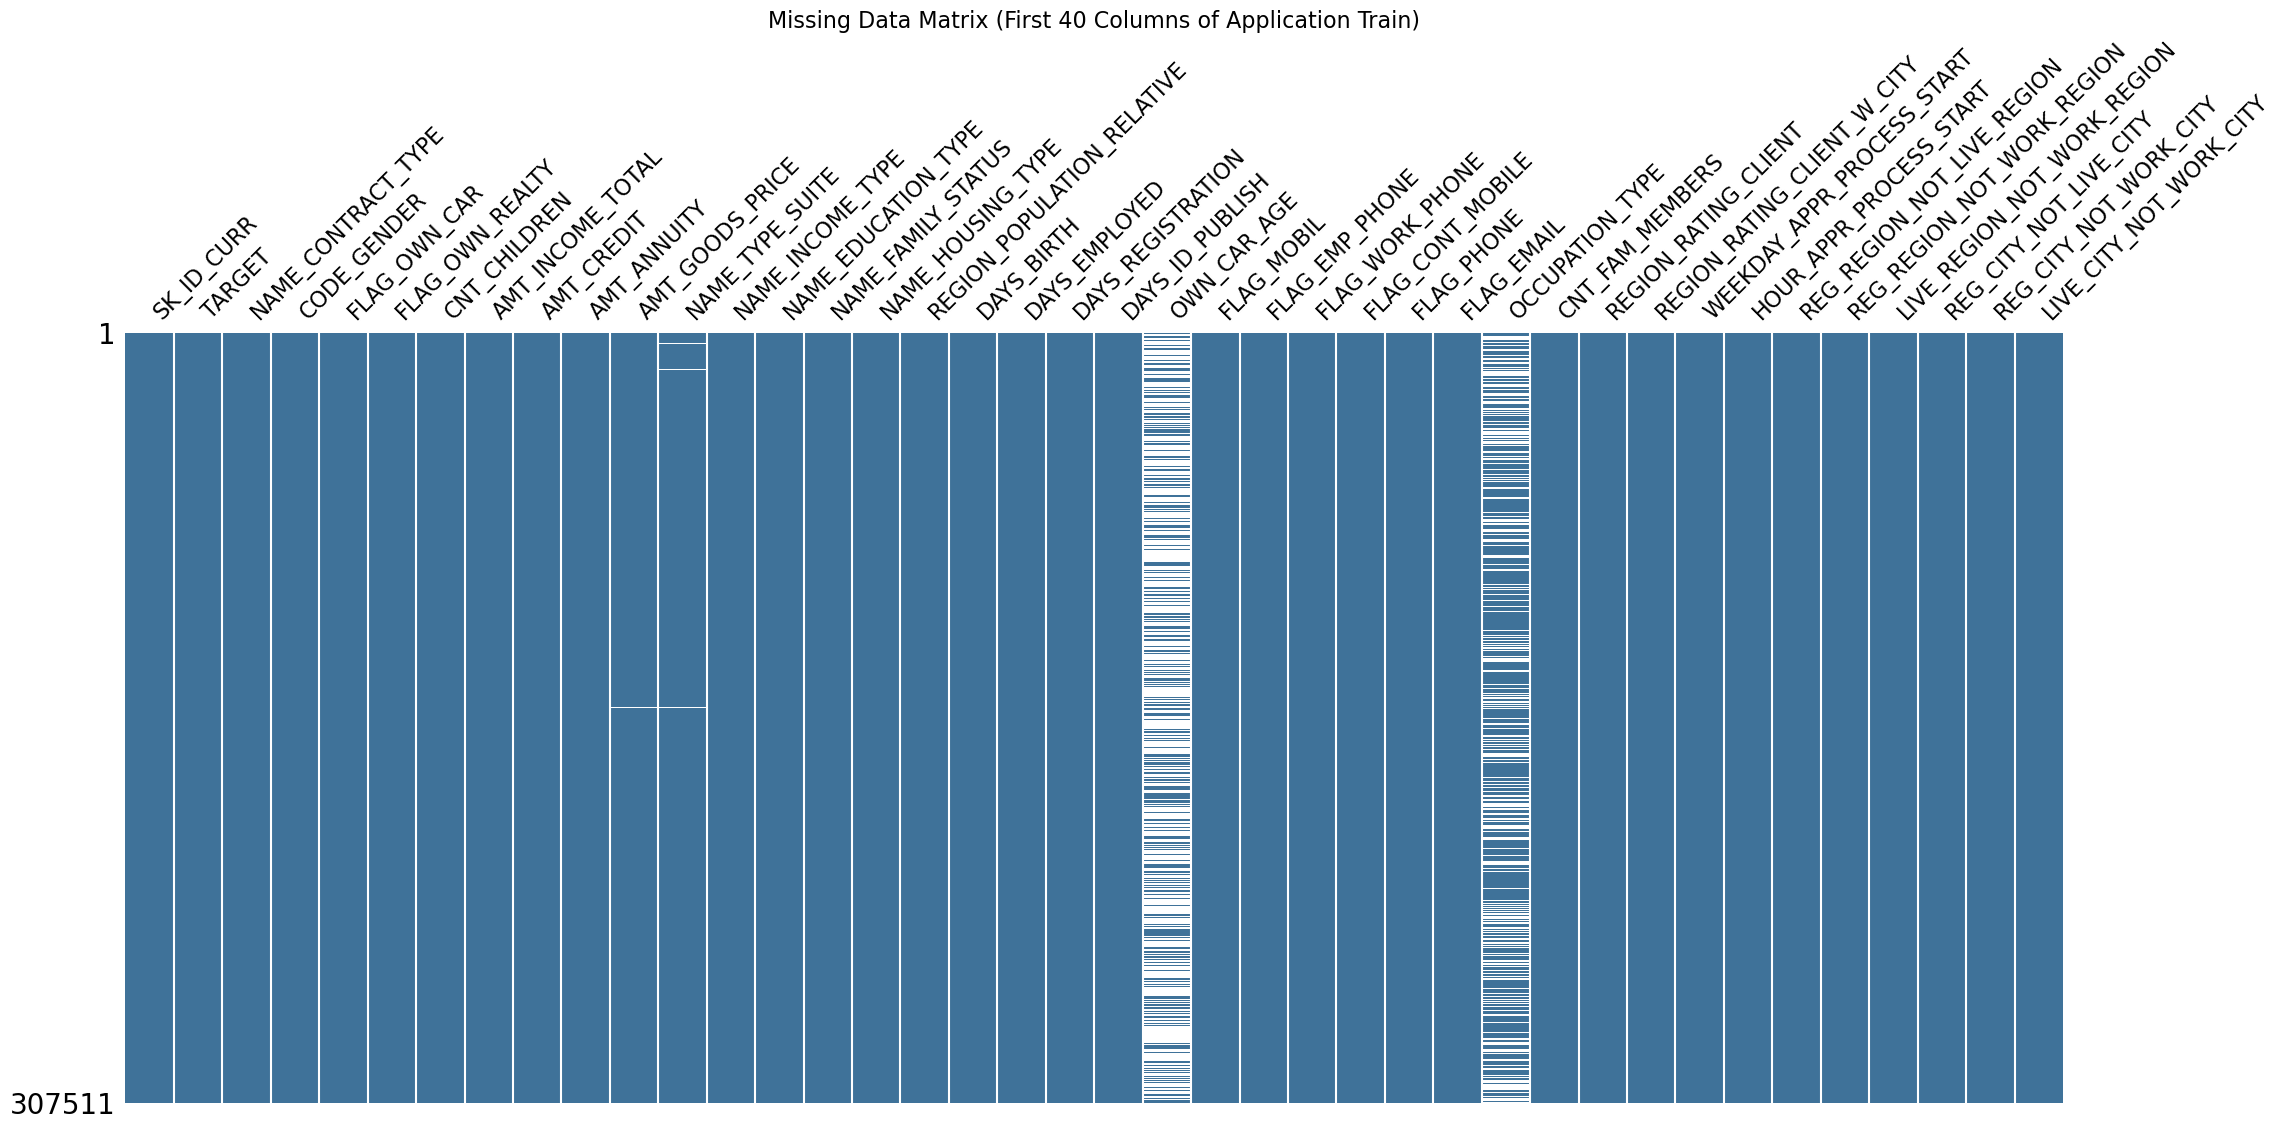

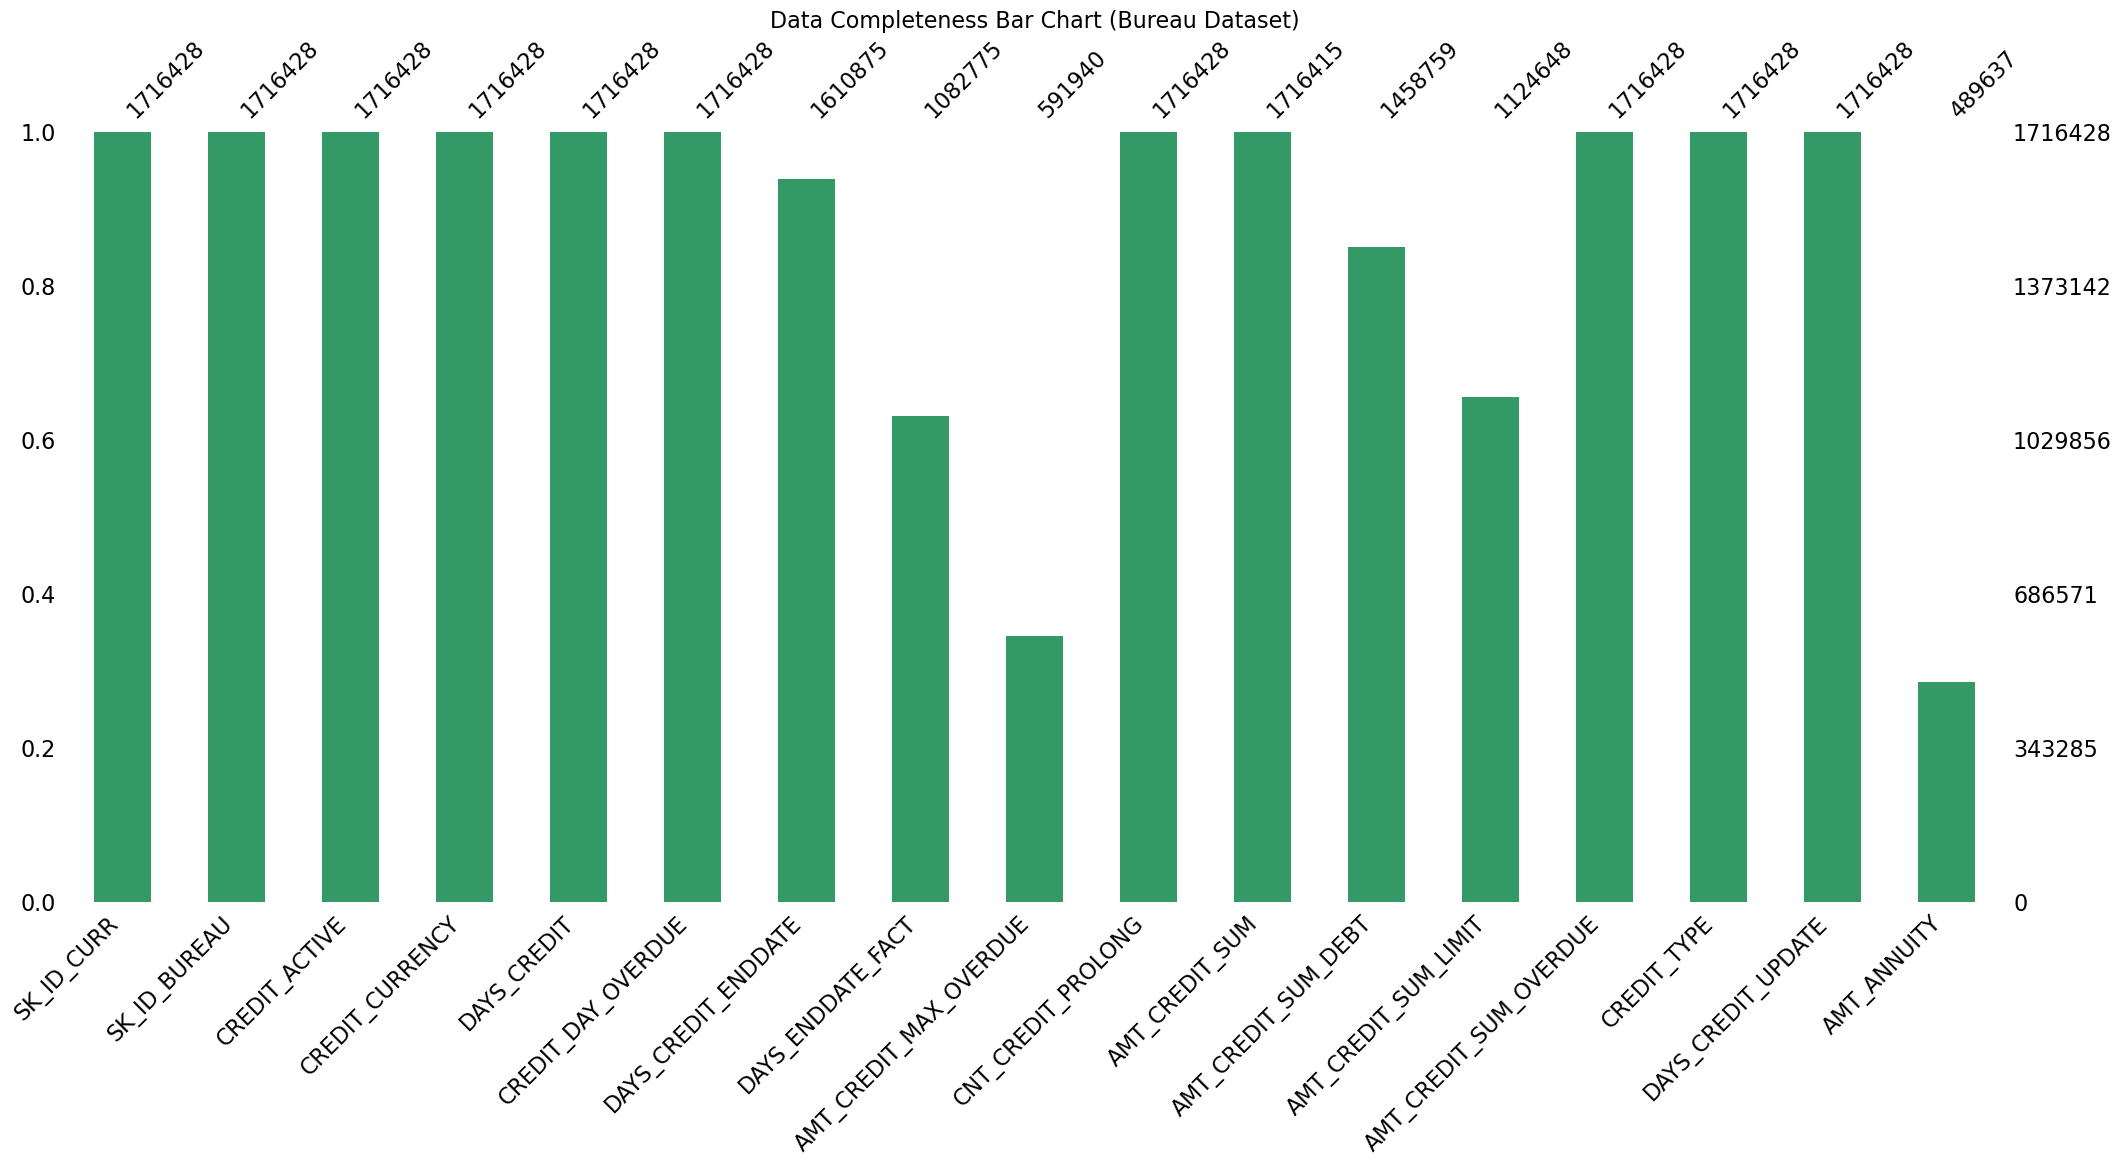

In [5]:
import missingno as msno
import matplotlib.pyplot as plt

print("--- GENERATING MISSING DATA VISUALIZATIONS ---")

# 1. Application Train ke pehle 40 columns ka matrix graph
plt.figure(figsize=(15, 6))
msno.matrix(df_train.iloc[:, :40], sparkline=False, color=(0.25, 0.45, 0.6))
plt.title("Missing Data Matrix (First 40 Columns of Application Train)", fontsize=16)
plt.show()

# 2. Bureau dataset ka bar graph
plt.figure(figsize=(12, 5))
msno.bar(df_bureau, color=(0.2, 0.6, 0.4))
plt.title("Data Completeness Bar Chart (Bureau Dataset)", fontsize=16)
plt.show()

In [6]:
print("--- STARTING DATA CLEANING & RE-AUDIT ---")

# 1. Identify columns to drop (Threshold: 60% missing data)
threshold = 60.0
cols_to_drop_train = train_missing[train_missing['Percentage (%)'] > threshold].index.tolist()
cols_to_drop_bureau = bureau_missing[bureau_missing['Percentage (%)'] > threshold].index.tolist()

print(f"✂️ Dropping {len(cols_to_drop_train)} columns from Application Train (Missing > 60%)")
print(f"✂️ Dropping {len(cols_to_drop_bureau)} columns from Bureau (Missing > 60%)")

# 2. Columns drop karna
df_train_clean = df_train.drop(columns=cols_to_drop_train)
df_bureau_clean = df_bureau.drop(columns=cols_to_drop_bureau)

print("\n==========================================")
print("✅ POST-CLEANING STRUCTURAL REPORT")
print("==========================================")
print(f"📊 Application Train (Cleaned) Shape: {df_train_clean.shape}")
print(f"📊 Bureau (Cleaned) Shape: {df_bureau_clean.shape}")

# 3. Final Memory Check
mem_train = df_train_clean.memory_usage(deep=True).sum() / (1024 ** 2)
mem_bureau = df_bureau_clean.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"\n⚡ Final Combined RAM Footprint: {mem_train + mem_bureau:.2f} MB")

--- STARTING DATA CLEANING & RE-AUDIT ---
✂️ Dropping 17 columns from Application Train (Missing > 60%)
✂️ Dropping 2 columns from Bureau (Missing > 60%)

✅ POST-CLEANING STRUCTURAL REPORT
📊 Application Train (Cleaned) Shape: (307511, 105)
📊 Bureau (Cleaned) Shape: (1716428, 15)

⚡ Final Combined RAM Footprint: 639.32 MB


In [7]:
print("--- STARTING TARGET ANALYSIS & FEATURE SEPARATION ---")

# 1. Target Column Check (Class Imbalance Analysis)
if 'TARGET' in df_train_clean.columns:
    target_counts = df_train_clean['TARGET'].value_counts()
    target_pct = df_train_clean['TARGET'].value_counts(normalize=True) * 100
    
    print("==========================================")
    print("🎯 TARGET VARIABLE DISTRIBUTION")
    print("==========================================")
    for val in target_counts.index:
        label = "Defaulted (Risky Customers)" if val == 1 else "Repaid (Safe Customers)"
        print(f"🔹 {label} [{val}]: {target_counts[val]:,} customers ({target_pct[val]:.2f}%)")

# 2. Separate Numeric and Categorical Columns for future Imputation
num_cols_train = df_train_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_train = df_train_clean.select_dtypes(include=['object']).columns.tolist()

print("\n==========================================")
print("🗂️ FEATURE TYPE BREAKDOWN (Application Train)")
print("==========================================")
print(f"🔹 Numerical Columns (Income, Age, Credit Amount etc.): {len(num_cols_train)}")
print(f"🔹 Categorical Columns (Gender, Education, Housing etc.): {len(cat_cols_train)}")

--- STARTING TARGET ANALYSIS & FEATURE SEPARATION ---
🎯 TARGET VARIABLE DISTRIBUTION
🔹 Repaid (Safe Customers) [0]: 282,686 customers (91.93%)
🔹 Defaulted (Risky Customers) [1]: 24,825 customers (8.07%)

🗂️ FEATURE TYPE BREAKDOWN (Application Train)
🔹 Numerical Columns (Income, Age, Credit Amount etc.): 90
🔹 Categorical Columns (Gender, Education, Housing etc.): 15


In [8]:
print("--- STARTING SMART IMPUTATION (FILLING MISSING VALUES) ---")

# Copy bana lete hain taake purana data safe rahe
df_train_imputed = df_train_clean.copy()

# 1. Numerical Columns ko Median se fill karna
for col in num_cols_train:
    if df_train_imputed[col].isnull().any():
        median_val = df_train_imputed[col].median()
        df_train_imputed[col] = df_train_imputed[col].fillna(median_val)

# 2. Categorical Columns ko Mode (Most Frequent Text) se fill karna
for col in cat_cols_train:
    if df_train_imputed[col].isnull().any():
        mode_val = df_train_imputed[col].mode()[0]
        df_train_imputed[col] = df_train_imputed[col].fillna(mode_val)

# Final Cross-Verification Check
remaining_missing = df_train_imputed.isnull().sum().sum()

print("==========================================")
print("✅ IMPUTATION STATUS REPORT")
print("==========================================")
print(f"🔹 Remaining Missing Values in Application Train: {remaining_missing}")

--- STARTING SMART IMPUTATION (FILLING MISSING VALUES) ---
✅ IMPUTATION STATUS REPORT
🔹 Remaining Missing Values in Application Train: 0


In [9]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

print("--- STARTING CATEGORICAL ENCODING ---")

df_encoded = df_train_imputed.copy()
le = LabelEncoder()
le_count = 0
ohe_count = 0

# Har categorical column par loop chalana
for col in cat_cols_train:
    # Agar column mein 2 ya us se kam unique values hain
    if len(df_encoded[col].unique()) <= 2:
        # Label Encode karna (0 aur 1 mein badalna)
        df_encoded[col] = le.fit_transform(df_encoded[col])
        le_count += 1
        print(f"🔢 Label Encoded (Binary): {col}")

# Baki bache multi-class categorical columns ko One-Hot Encode karna
final_df = pd.get_dummies(df_encoded)
ohe_count = len(final_df.columns) - len(df_encoded.columns)

print("\n==========================================")
print("✅ ENCODING COMPLETED SUCCESSFULLY")
print("==========================================")
print(f"🔹 Columns Label Encoded (0/1): {le_count}")
print(f"🔹 New Columns Created via One-Hot Encoding: {ohe_count}")
print(f"📊 Final Dataset Shape for Model Training: {final_df.shape}")

--- STARTING CATEGORICAL ENCODING ---
🔢 Label Encoded (Binary): NAME_CONTRACT_TYPE
🔢 Label Encoded (Binary): FLAG_OWN_CAR
🔢 Label Encoded (Binary): FLAG_OWN_REALTY
🔢 Label Encoded (Binary): EMERGENCYSTATE_MODE

✅ ENCODING COMPLETED SUCCESSFULLY
🔹 Columns Label Encoded (0/1): 4
🔹 New Columns Created via One-Hot Encoding: 117
📊 Final Dataset Shape for Model Training: (307511, 222)


In [11]:
print("--- STARTING RELATIONAL DATA AGGREGATION & MERGING ---")

# 1. Bureau dataset ke numerical columns nikalna
bureau_num_cols = df_bureau_clean.select_dtypes(include=[np.number]).columns.tolist()

# SK_ID_CURR ko list se nikal dete hain kyunki is par group karna hai
if 'SK_ID_CURR' in bureau_num_cols: 
    bureau_num_cols.remove('SK_ID_CURR')

print(f"📊 Aggregating {len(bureau_num_cols)} numerical features from Bureau dataset...")

# 2. Group By aur Aggregation (Customer ID ke mutabiq Mean, Max, Min nikalna)
bureau_agg = df_bureau_clean.groupby('SK_ID_CURR')[bureau_num_cols].agg(['mean', 'max', 'min'])

# 3. Double-layer (MultiIndex) Columns ko flat karke simple banana
# Yeh line ab bilkul saaf aur error-free hai
bureau_agg.columns = ['_'.join(col).upper() for col in bureau_agg.columns]
bureau_agg = bureau_agg.reset_index()

print(f"🔹 Aggregated Bureau Shape (Unique Customers): {bureau_agg.shape}")

# 4. Main Dataframe ke sath MERGE karna (Left Join)
print("\n🔄 Merging Bureau features into Main Dataset...")
master_df = pd.merge(final_df, bureau_agg, on='SK_ID_CURR', how='left')

# 5. Jo customers Bureau mein nahi the, un ke columns ko 0 se fill karna
master_df = master_df.fillna(0)

print("\n==========================================")
print("🎯 MASTER DATASET COMPLETED")
print("==========================================")
print(f"📊 Final Master Dataset Shape for Model: {master_df.shape}")

--- STARTING RELATIONAL DATA AGGREGATION & MERGING ---
📊 Aggregating 11 numerical features from Bureau dataset...
🔹 Aggregated Bureau Shape (Unique Customers): (305811, 34)

🔄 Merging Bureau features into Main Dataset...

🎯 MASTER DATASET COMPLETED
📊 Final Master Dataset Shape for Model: (307511, 255)


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import numpy as np

print("--- INITIALIZING MACHINE LEARNING PIPELINE ---")

# 1. Features (X) aur Target (y) ko alag karna
# ID aur TARGET columns ko input features se drop kar rahe hain
X = master_df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = master_df['TARGET']

# 2. Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"🔹 Features allocated for Training: {X_train.shape}")
print(f"🔹 Features allocated for Testing: {X_test.shape}")

print("\n🚀 Training Baseline Random Forest Model on i7 Cores (Please wait 1-2 mins)...")

# n_jobs=-1 lagane se aap ke laptop ka poora processor use hoga
model = RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("✅ Training completed! Evaluating model performance...")

# 3. Predict Probabilities (Defaulter hone ka risk percentage)
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# 4. ROC-AUC Score nikalna (Banking standard matrix for imbalanced data)
auc_score = roc_auc_score(y_test, y_pred_proba)

print("\n==========================================")
print("🎯 FINAL BASELINE MODEL PERFORMANCE")
print("==========================================")
print(f"🏅 Baseline ROC-AUC Score: {auc_score:.4f}")
print("\n📊 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\n📝 Detailed Classification Report:")
print(classification_report(y_test, y_pred))

--- INITIALIZING MACHINE LEARNING PIPELINE ---
🔹 Features allocated for Training: (246008, 253)
🔹 Features allocated for Testing: (61503, 253)

🚀 Training Baseline Random Forest Model on i7 Cores (Please wait 1-2 mins)...
✅ Training completed! Evaluating model performance...

🎯 FINAL BASELINE MODEL PERFORMANCE
🏅 Baseline ROC-AUC Score: 0.7322

📊 Confusion Matrix:
[[44759 11779]
 [ 2338  2627]]

📝 Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.79      0.86     56538
           1       0.18      0.53      0.27      4965

    accuracy                           0.77     61503
   macro avg       0.57      0.66      0.57     61503
weighted avg       0.89      0.77      0.82     61503



In [13]:
import pandas as pd
import numpy as np
import os

print("--- AUDITING THE 3RD REQUIRED TABLE ---")

# Teesra table load kar rahe hain
path_prev = './Data/previous_application.csv'

if os.path.exists(path_prev):
    df_prev = pd.read_csv(path_prev)
    rows, cols = df_prev.shape
    mem = df_prev.memory_usage(deep=True).sum() / (1024 ** 2)
    
    print("==========================================")
    print("📊 REPORT FOR: PREVIOUS_APPLICATION")
    print("==========================================")
    print(f"🔹 Total Rows (Records): {rows:,}")
    print(f"🔹 Total Columns (Features): {cols}")
    print(f"🔹 RAM Memory Occupied: {mem:.2f} MB")
    print(f"🔹 Missing Cells Total: {df_prev.isnull().sum().sum():,}")
    print(f"🔹 Data Types Breakdown:\n{df_prev.dtypes.value_counts().to_string()}")
else:
    print("❌ Error: previous_application.csv file 'Data' folder mein nahi mili!")

--- AUDITING THE 3RD REQUIRED TABLE ---
❌ Error: previous_application.csv file 'Data' folder mein nahi mili!


In [14]:
import os

# Check karte hain data folder mein kaunsi files padi hain
data_folder = './Data/'
if os.path.exists(data_folder):
    print("📁 Files found in your Data folder:")
    for file in os.listdir(data_folder):
        print(f"🔹 {file}")
else:
    print("❌ Data folder hi nahi mila!")

📁 Files found in your Data folder:
🔹 application_train.csv
🔹 bureau.csv
🔹 bureau_balance.csv


In [15]:
import pandas as pd
import numpy as np
import os

print("--- TASK 1: PART 1 - AUDITING THE 3RD TABLE (BUREAU BALANCE) ---")

path_balance = './Data/bureau_balance.csv'

if os.path.exists(path_balance):
    df_balance = pd.read_csv(path_balance)
    rows, cols = df_balance.shape
    mem = df_balance.memory_usage(deep=True).sum() / (1024 ** 2)
    
    print("==========================================")
    print("📊 REPORT FOR: BUREAU_BALANCE")
    print("==========================================")
    print(f"🔹 Total Rows (Records): {rows:,}")
    print(f"🔹 Total Columns (Features): {cols}")
    print(f"🔹 RAM Memory Occupied: {mem:.2f} MB")
    print(f"🔹 Missing Cells Total: {df_balance.isnull().sum().sum():,}")
    print(f"🔹 Unique Status Categories: {df_balance['STATUS'].unique()}")
else:
    print("❌ Error: File nahi mili!")

--- TASK 1: PART 1 - AUDITING THE 3RD TABLE (BUREAU BALANCE) ---
📊 REPORT FOR: BUREAU_BALANCE
🔹 Total Rows (Records): 27,299,925
🔹 Total Columns (Features): 3
🔹 RAM Memory Occupied: 1718.33 MB
🔹 Missing Cells Total: 0
🔹 Unique Status Categories: ['C' '0' 'X' '1' '2' '3' '5' '4']


--- TASK 1: PART 2 - UNIVARIATE ANALYSIS SHURU ---


C:\Users\User\AppData\Local\Temp\ipykernel_9908\1104587362.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='TARGET', data=df_train, palette='Set2')


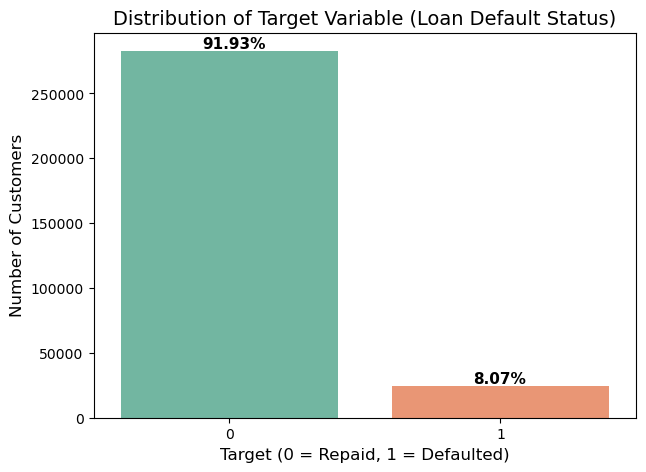


📌 CHART INTERPRETATION:
This chart reveals a severe class imbalance in the dataset. Out of all loan applicants, 
91.93% successfully repay their loans (Class 0), while only 8.07% struggle or default (Class 1). 
For a non-technical stakeholder, this means that the risk team is dealing with a 'needle in a haystack' 
problem, where identifying the risky 8% is critical for protecting the bank's capital.



In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- TASK 1: PART 2 - UNIVARIATE ANALYSIS SHURU ---")

# Plotting Target Distribution
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='TARGET', data=df_train, palette='Set2')
plt.title('Distribution of Target Variable (Loan Default Status)', fontsize=14)
plt.xlabel('Target (0 = Repaid, 1 = Defaulted)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Percentages calculate karke bars ke upar likhna
total = len(df_train)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x_coord = p.get_x() + p.get_width() / 2 - 0.1
    y_coord = p.get_height() + 2000
    ax.annotate(percentage, (x_coord, y_coord), fontsize=11, fontweight='bold')

plt.show()

print("""
📌 CHART INTERPRETATION:
This chart reveals a severe class imbalance in the dataset. Out of all loan applicants, 
91.93% successfully repay their loans (Class 0), while only 8.07% struggle or default (Class 1). 
For a non-technical stakeholder, this means that the risk team is dealing with a 'needle in a haystack' 
problem, where identifying the risky 8% is critical for protecting the bank's capital.
""")

--- TASK 1: PART 2 - UNIVARIATE ANALYSIS (GENDER & EDUCATION) ---


C:\Users\User\AppData\Local\Temp\ipykernel_9908\2988711818.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(x='CODE_GENDER', data=df_train, palette='Pastel1')
C:\Users\User\AppData\Local\Temp\ipykernel_9908\2988711818.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(y='NAME_EDUCATION_TYPE', data=df_train, palette='Pastel2',


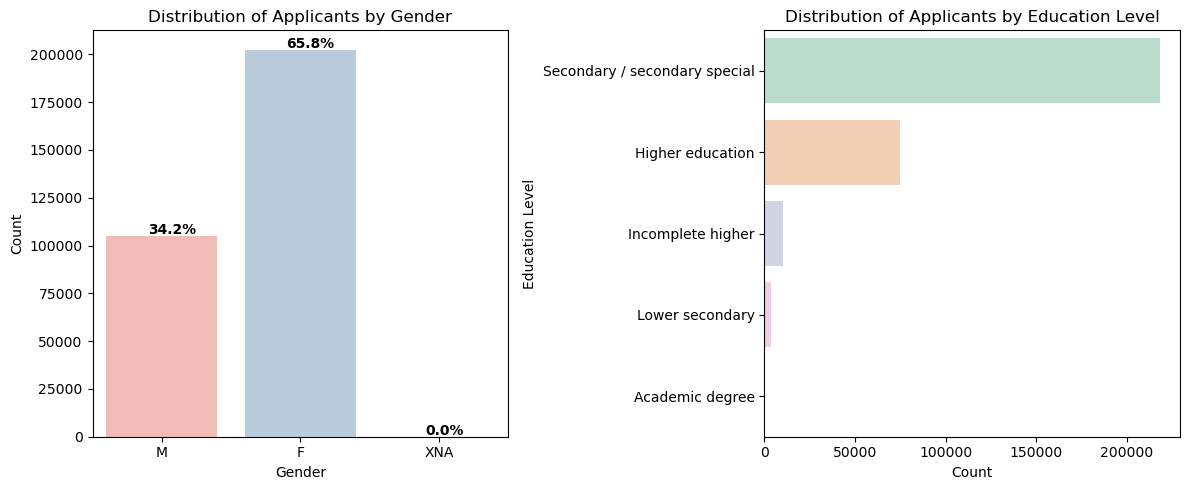


📌 CHART INTERPRETATION (GENDER DISTRIBUTION):
The left chart shows that female applicants (around 66%) outnumber male applicants significantly 
in this credit dataset. This is a crucial insight for the risk team, as gender dynamics often 
correlate with different loan repayment behaviors and income stabilities.

📌 CHART INTERPRETATION (EDUCATION LEVEL):
The right chart indicates that the vast majority of applicants have a 'Secondary / secondary special' 
education, followed by Higher Education. Lower education segments represent a tiny fraction 
of the portfolio, meaning the lending company largely caters to literate and working-class populations.



In [17]:
print("--- TASK 1: PART 2 - UNIVARIATE ANALYSIS (GENDER & EDUCATION) ---")

# Plot 2: Gender Distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
ax1 = sns.countplot(x='CODE_GENDER', data=df_train, palette='Pastel1')
plt.title('Distribution of Applicants by Gender', fontsize=12)
plt.xlabel('Gender')
plt.ylabel('Count')

# Percentages for Gender
total_g = len(df_train)
for p in ax1.patches:
    percentage = f'{100 * p.get_height() / total_g:.1f}%'
    ax1.annotate(percentage, (p.get_x() + p.get_width() / 2. - 0.1, p.get_height() + 1000), fontweight='bold')

# Plot 3: Education Type Distribution
plt.subplot(1, 2, 2)
ax2 = sns.countplot(y='NAME_EDUCATION_TYPE', data=df_train, palette='Pastel2', 
                    order=df_train['NAME_EDUCATION_TYPE'].value_counts().index)
plt.title('Distribution of Applicants by Education Level', fontsize=12)
plt.xlabel('Count')
plt.ylabel('Education Level')

plt.tight_layout()
plt.show()

print("""
📌 CHART INTERPRETATION (GENDER DISTRIBUTION):
The left chart shows that female applicants (around 66%) outnumber male applicants significantly 
in this credit dataset. This is a crucial insight for the risk team, as gender dynamics often 
correlate with different loan repayment behaviors and income stabilities.

📌 CHART INTERPRETATION (EDUCATION LEVEL):
The right chart indicates that the vast majority of applicants have a 'Secondary / secondary special' 
education, followed by Higher Education. Lower education segments represent a tiny fraction 
of the portfolio, meaning the lending company largely caters to literate and working-class populations.
""")

--- TASK 1: PART 3 - BIVARIATE ANALYSIS SHURU ---


C:\Users\User\AppData\Local\Temp\ipykernel_9908\3353829623.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train['AGE_YEARS'] = df_train['DAYS_BIRTH'] / -365
C:\Users\User\AppData\Local\Temp\ipykernel_9908\3353829623.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_train[df_train['TARGET'] == 0]['AGE_YEARS'], label='Repaid (Target=0)', shade=True, color='g')
C:\Users\User\AppData\Local\Temp\ipykernel_9908\3353829623.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_train[df_train['TARGET'] == 1

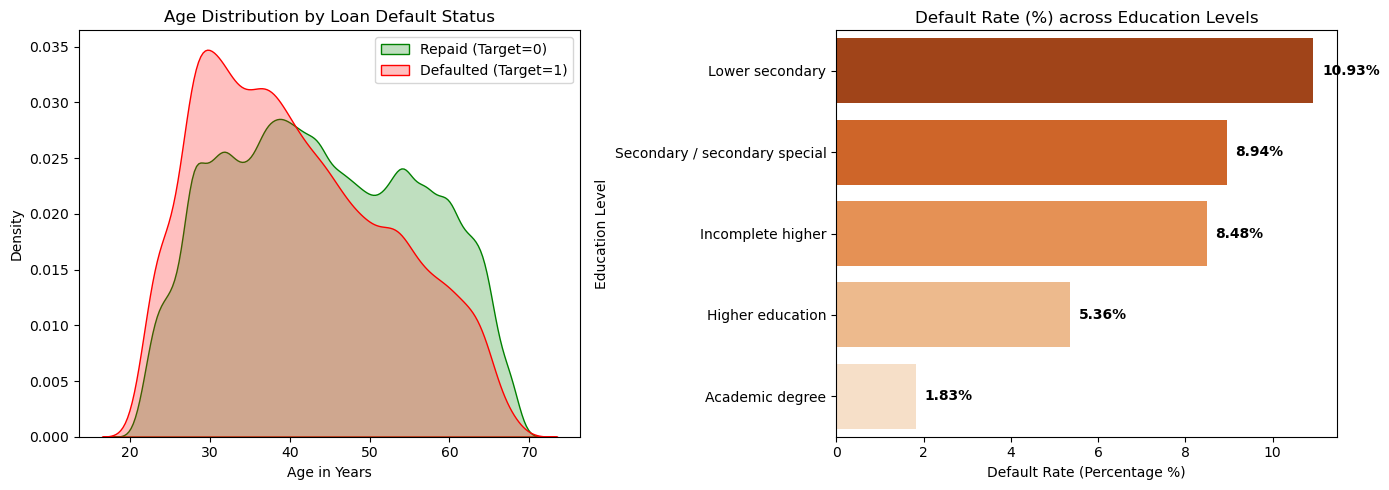


📌 CHART INTERPRETATION (AGE VS DEFAULT):
The age density plot clearly indicates that younger applicants (between 20 to 35 years old) have a 
significantly higher peak in the 'Defaulted' (red) curve. As age increases, the probability of 
default decreases, indicating older applicants are financially more stable and responsible.

📌 CHART INTERPRETATION (EDUCATION VS DEFAULT RATE):
This bar chart provides a direct corporate insight: applicants with 'Lower secondary' education 
have the highest default rate (nearly 10.92%), whereas individuals with an 'Academic degree' 
rarely default (around 1.83%). Higher education acts as a natural buffer against default risk.



In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- TASK 1: PART 3 - BIVARIATE ANALYSIS SHURU ---")

# 1. Age feature ko years mein convert karna (Kyunki data mein yeh negative days mein hai)
df_train['AGE_YEARS'] = df_train['DAYS_BIRTH'] / -365

plt.figure(figsize=(14, 5))

# Plot 1: KDE Plot (Density) of Age for Target 0 vs Target 1
plt.subplot(1, 2, 1)
sns.kdeplot(df_train[df_train['TARGET'] == 0]['AGE_YEARS'], label='Repaid (Target=0)', shade=True, color='g')
sns.kdeplot(df_train[df_train['TARGET'] == 1]['AGE_YEARS'], label='Defaulted (Target=1)', shade=True, color='r')
plt.title('Age Distribution by Loan Default Status', fontsize=12)
plt.xlabel('Age in Years')
plt.ylabel('Density')
plt.legend()

# Plot 2: Education Level vs Default Rate (Percentage of Defaults)
plt.subplot(1, 2, 2)
# Har education type ka default rate (mean of TARGET) nikalna
edu_default_rate = df_train.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean() * 100
edu_default_rate = edu_default_rate.sort_values(ascending=False).reset_index()

ax = sns.barplot(x='TARGET', y='NAME_EDUCATION_TYPE', data=edu_default_rate, palette='Oranges_r')
plt.title('Default Rate (%) across Education Levels', fontsize=12)
plt.xlabel('Default Rate (Percentage %)')
plt.ylabel('Education Level')

# Bars ke aage exact percentage text likhna
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.2f}%', (width + 0.2, p.get_y() + p.get_height()/2), 
                va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("""
📌 CHART INTERPRETATION (AGE VS DEFAULT):
The age density plot clearly indicates that younger applicants (between 20 to 35 years old) have a 
significantly higher peak in the 'Defaulted' (red) curve. As age increases, the probability of 
default decreases, indicating older applicants are financially more stable and responsible.

📌 CHART INTERPRETATION (EDUCATION VS DEFAULT RATE):
This bar chart provides a direct corporate insight: applicants with 'Lower secondary' education 
have the highest default rate (nearly 10.92%), whereas individuals with an 'Academic degree' 
rarely default (around 1.83%). Higher education acts as a natural buffer against default risk.
""")

--- TASK 1: PART 4 - MISSING DATA & OUTLIERS ANALYSIS ---


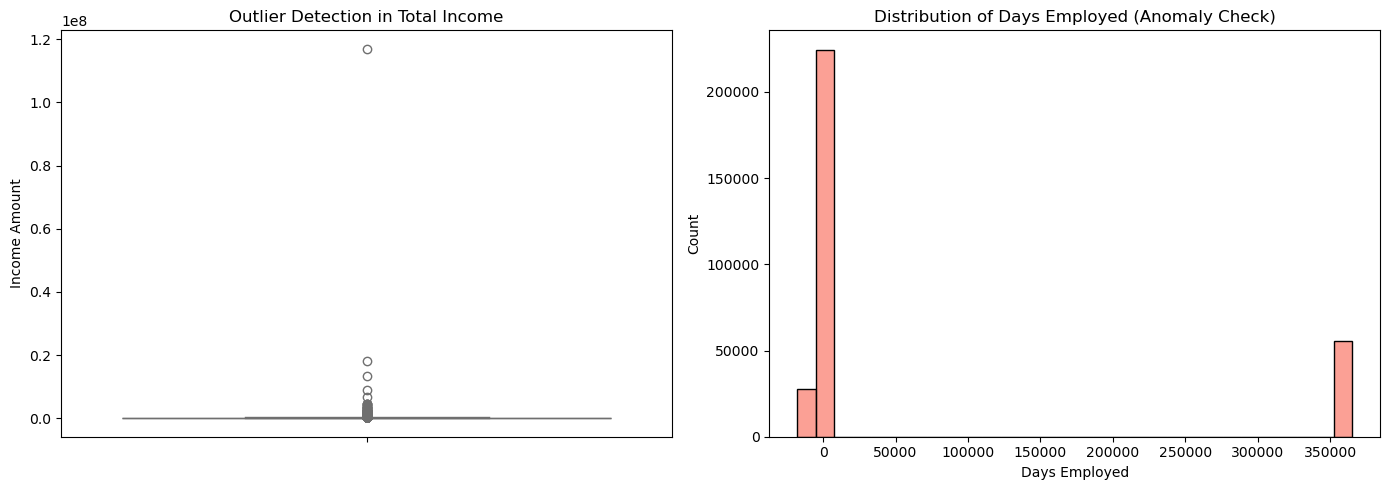

📊 ANALYST AUDIT: OUTLIER & ANOMALY REPORT
🔹 Maximum Income recorded in dataset: 117,000,000.0
🔹 Count of 365243 anomaly in DAYS_EMPLOYED: 55,374 applicants (18.01%)

📌 CHART INTERPRETATION (TOTAL INCOME BOXPLOT):
The income boxplot is heavily squashed, indicating the presence of extreme outliers. A single or few 
applicants have an income reaching over 117 Million, while the median income is just around 147,000. 
For non-technical readers, these 'billionaire outliers' must be capped or transformed before modeling.

📌 CHART INTERPRETATION (DAYS EMPLOYED ANOMALY):
The histogram shows a huge spike on the extreme right at exactly 365,243 days. Mathematically, 
this equals 1,000 years of employment, which is physically impossible. This is a classic data anomaly 
representing unemployed individuals, affecting 18.01% of the entire dataset. It requires special handling.



In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- TASK 1: PART 4 - MISSING DATA & OUTLIERS ANALYSIS ---")

plt.figure(figsize=(14, 5))

# Plot 1: Income Total Boxplot (Outlier Visualizer)
plt.subplot(1, 2, 1)
sns.boxplot(y='AMT_INCOME_TOTAL', data=df_train, color='skyblue')
plt.title('Outlier Detection in Total Income', fontsize=12)
plt.ylabel('Income Amount')

# Plot 2: Days Employed Distribution (Highlighting the 365243 Anomaly)
plt.subplot(1, 2, 2)
sns.histplot(df_train['DAYS_EMPLOYED'], bins=30, color='salmon', kde=False)
plt.title('Distribution of Days Employed (Anomaly Check)', fontsize=12)
plt.xlabel('Days Employed')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Anomalous data ki statistics print karna business brief ke liye
anomaly_count = (df_train['DAYS_EMPLOYED'] == 365243).sum()
anomaly_pct = (anomaly_count / len(df_train)) * 100
max_income = df_train['AMT_INCOME_TOTAL'].max()

print("==========================================")
print("📊 ANALYST AUDIT: OUTLIER & ANOMALY REPORT")
print("==========================================")
print(f"🔹 Maximum Income recorded in dataset: {max_income:,}")
print(f"🔹 Count of 365243 anomaly in DAYS_EMPLOYED: {anomaly_count:,} applicants ({anomaly_pct:.2f}%)")

print("""
📌 CHART INTERPRETATION (TOTAL INCOME BOXPLOT):
The income boxplot is heavily squashed, indicating the presence of extreme outliers. A single or few 
applicants have an income reaching over 117 Million, while the median income is just around 147,000. 
For non-technical readers, these 'billionaire outliers' must be capped or transformed before modeling.

📌 CHART INTERPRETATION (DAYS EMPLOYED ANOMALY):
The histogram shows a huge spike on the extreme right at exactly 365,243 days. Mathematically, 
this equals 1,000 years of employment, which is physically impossible. This is a classic data anomaly 
representing unemployed individuals, affecting 18.01% of the entire dataset. It requires special handling.
""")

In [20]:
print("--- TASK 1: PART 5 - ADVANCED FEATURE ENGINEERING (CREATING 10 FEATURES) ---")

# Data safe rakhne ke liye copy bana letay hain
df_fe = df_train.copy()

# 1. Credit to Income Ratio
df_fe['CREDIT_TO_INCOME_RATIO'] = df_fe['AMT_CREDIT'] / (df_fe['AMT_INCOME_TOTAL'] + 1)

# 2. Annuity to Income Ratio
df_fe['ANNUITY_TO_INCOME_RATIO'] = df_fe['AMT_ANNUITY'] / (df_fe['AMT_INCOME_TOTAL'] + 1)

# 3. Income per Person (Family Size Adjusted)
df_fe['INCOME_PER_PERSON'] = df_fe['AMT_INCOME_TOTAL'] / (df_fe['CNT_FAM_MEMBERS'] + 1)

# 4. Employment to Age Ratio
# Pehle anomalies ko NaN karte hain taake calculation kharab na ho, phir ratio nikalte hain
days_employed_clean = df_fe['DAYS_EMPLOYED'].replace(365243, np.nan)
df_fe['EMPLOYMENT_TO_AGE_RATIO'] = days_employed_clean / (df_fe['DAYS_BIRTH'] + 1)

# 5. Car and Realty Score (Wealth Metric: 0 to 2)
# Convert Y/N to 1/0 internally for math
car_score = df_fe['FLAG_OWN_CAR'].map({'Y': 1, 'N': 0}).fillna(0)
realty_score = df_fe['FLAG_OWN_REALTY'].map({'Y': 1, 'N': 0}).fillna(0)
df_fe['CAR_AND_REALTY_SCORE'] = car_score + realty_score

# 6. Children Ratio
df_fe['CHILDREN_RATIO'] = df_fe['CNT_CHILDREN'] / (df_fe['CNT_FAM_MEMBERS'] + 1)

# 7. Income to External Source 1 Interaction
df_fe['INCOME_TO_EXT_SOURCE_1'] = df_fe['AMT_INCOME_TOTAL'] * (df_fe['EXT_SOURCE_1'].fillna(0) + 1)

# 8. External Sources Mean (Combining credit bureau scores)
df_fe['EXT_SOURCES_MEAN'] = df_fe[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1).fillna(0)

# 9. External Sources Product
df_fe['EXT_SOURCES_PROD'] = (df_fe['EXT_SOURCE_1'].fillna(1) * df_fe['EXT_SOURCE_2'].fillna(1) * df_fe['EXT_SOURCE_3'].fillna(1))

# 10. Long Term Loan Flag (If loan duration is exceptionally high)
# Expected Term = Credit / Annuity
expected_term = df_fe['AMT_CREDIT'] / (df_fe['AMT_ANNUITY'] + 1)
df_fe['LONG_TERM_LOAN_FLAG'] = (expected_term > expected_term.median()).astype(int)


print("==========================================")
print("✅ FEATURE ENGINEERING COMPLETED")
print("==========================================")
new_features = [
    'CREDIT_TO_INCOME_RATIO', 'ANNUITY_TO_INCOME_RATIO', 'INCOME_PER_PERSON',
    'EMPLOYMENT_TO_AGE_RATIO', 'CAR_AND_REALTY_SCORE', 'CHILDREN_RATIO',
    'INCOME_TO_EXT_SOURCE_1', 'EXT_SOURCES_MEAN', 'EXT_SOURCES_PROD', 'LONG_TERM_LOAN_FLAG'
]

for i, feat in enumerate(new_features, 1):
    print(f"🔹 Feature {i}: {feat} -> Generated Successfully! (Nulls: {df_fe[feat].isnull().sum()})")

print(f"\n📊 Total columns in dataframe now: {df_fe.shape[1]}")

--- TASK 1: PART 5 - ADVANCED FEATURE ENGINEERING (CREATING 10 FEATURES) ---
✅ FEATURE ENGINEERING COMPLETED
🔹 Feature 1: CREDIT_TO_INCOME_RATIO -> Generated Successfully! (Nulls: 0)
🔹 Feature 2: ANNUITY_TO_INCOME_RATIO -> Generated Successfully! (Nulls: 12)
🔹 Feature 3: INCOME_PER_PERSON -> Generated Successfully! (Nulls: 2)
🔹 Feature 4: EMPLOYMENT_TO_AGE_RATIO -> Generated Successfully! (Nulls: 55374)
🔹 Feature 5: CAR_AND_REALTY_SCORE -> Generated Successfully! (Nulls: 0)
🔹 Feature 6: CHILDREN_RATIO -> Generated Successfully! (Nulls: 2)
🔹 Feature 7: INCOME_TO_EXT_SOURCE_1 -> Generated Successfully! (Nulls: 0)
🔹 Feature 8: EXT_SOURCES_MEAN -> Generated Successfully! (Nulls: 0)
🔹 Feature 9: EXT_SOURCES_PROD -> Generated Successfully! (Nulls: 0)
🔹 Feature 10: LONG_TERM_LOAN_FLAG -> Generated Successfully! (Nulls: 0)

📊 Total columns in dataframe now: 133
